In [117]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib import style
from sklearn.decomposition import PCA
import matplotlib.cm as cm
from sklearn.preprocessing import PolynomialFeatures
from matplotlib import *
from pylab import rcParams
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import scale
from collections import Counter

In [118]:
%matplotlib inline
rcParams['figure.figsize'] = 5, 4
sns.set_style('whitegrid')
# Laod the dataset
df = pd.read_csv('kc_house.csv')

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [119]:
# Lets see the some important stats
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


# Look at the bedroom columns , the dataset has a house where the house has 33 bedrooms , seems to be a massive house and would be interesting to know more about it as we progress.
# Maximum square feet is 13,450 where as the minimum is 290. we can see that the data is distributed.
# Similarly , we can infer so many things by just looking at the describe function.
# Now , we are going to see some visualization and also going to see how and what can we infer from visualization.


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
id               21613 non-null int64
date             21613 non-null object
price            21613 non-null float64
bedrooms         21613 non-null int64
bathrooms        21613 non-null float64
sqft_living      21613 non-null int64
sqft_lot         21613 non-null int64
floors           21613 non-null float64
waterfront       21613 non-null int64
view             21613 non-null int64
condition        21613 non-null int64
grade            21613 non-null int64
sqft_above       21613 non-null int64
sqft_basement    21613 non-null int64
yr_built         21613 non-null int64
yr_renovated     21613 non-null int64
zipcode          21613 non-null int64
lat              21613 non-null float64
long             21613 non-null float64
sqft_living15    21613 non-null int64
sqft_lot15       21613 non-null int64
dtypes: float64(5), int64(15), object(1)
memory usage: 3.5+ MB


In [122]:
df.shape

(21613, 21)

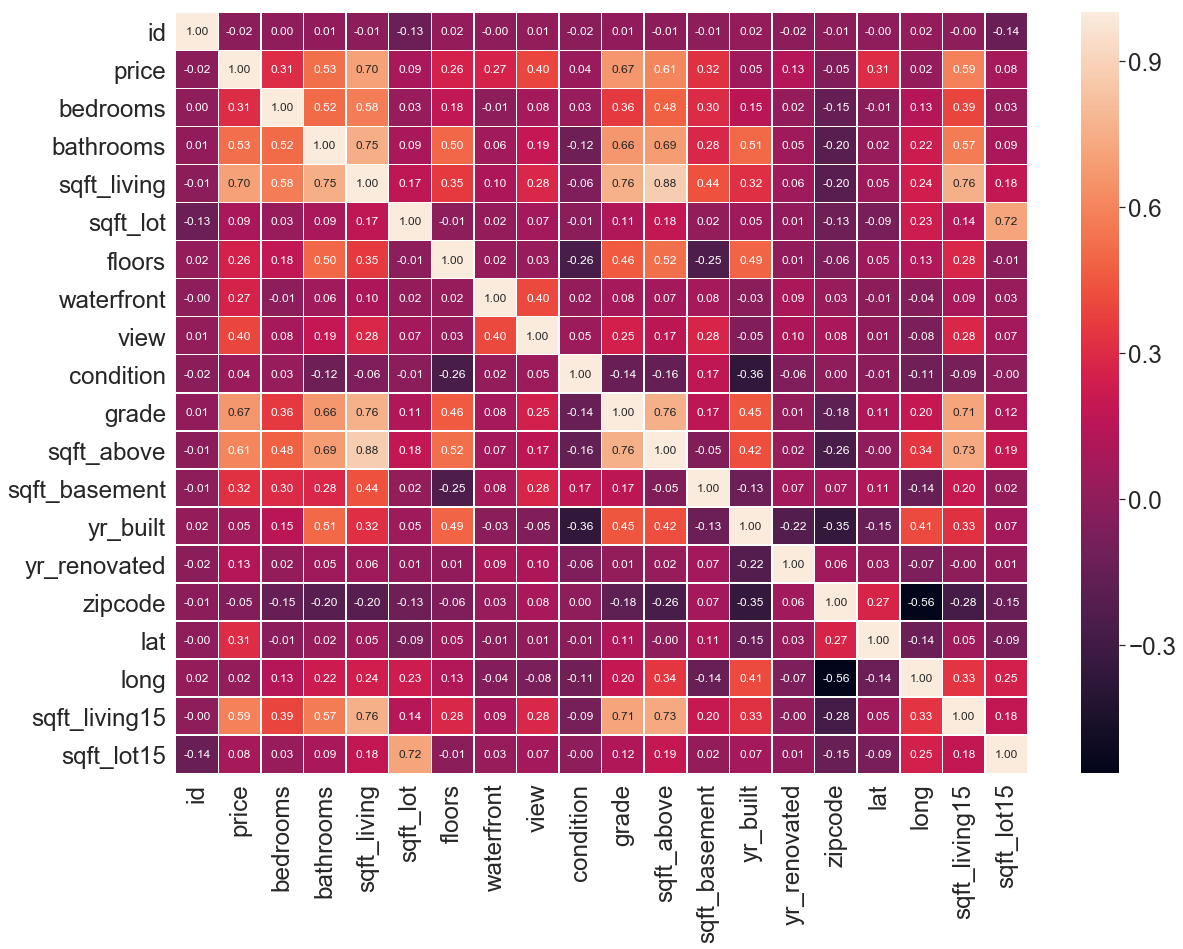

In [123]:
#df correlation matrix shows relations between all variables in the dataset  
f,ax = plt.subplots(figsize=(17, 14))
sns.heatmap(df.corr(), annot=True,annot_kws={'size': 12}, linewidths=.5, fmt='.2f', ax=ax)

# Getting insight of data using scatter plot (Feature vs Price)

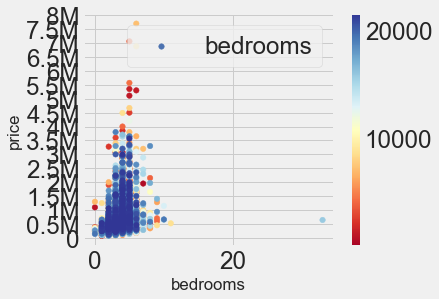

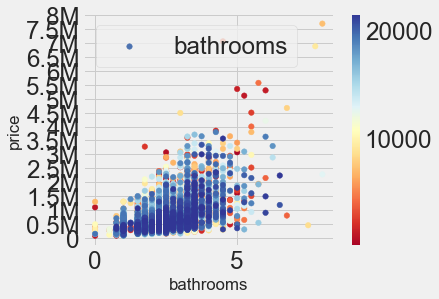

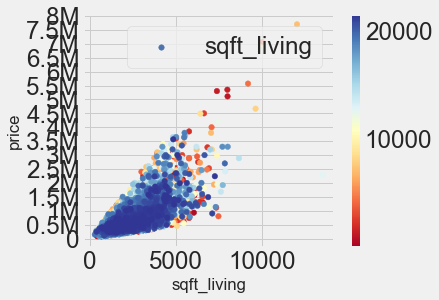

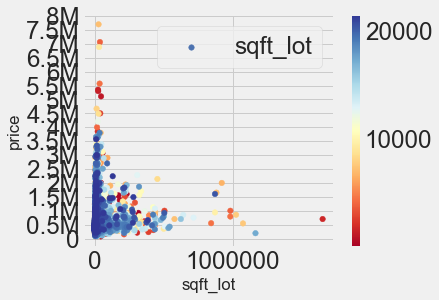

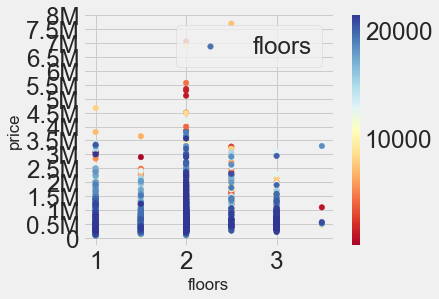

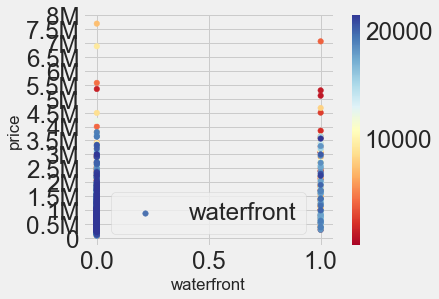

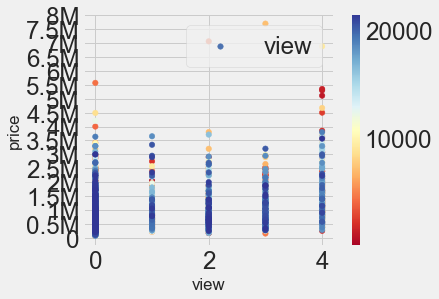

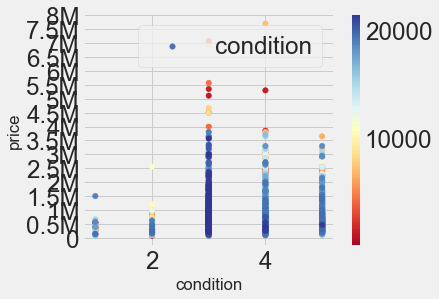

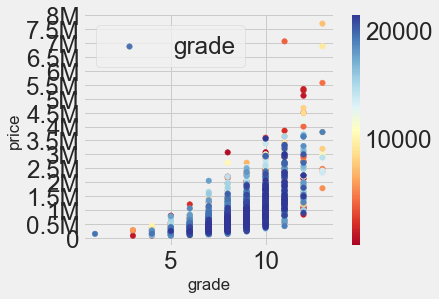

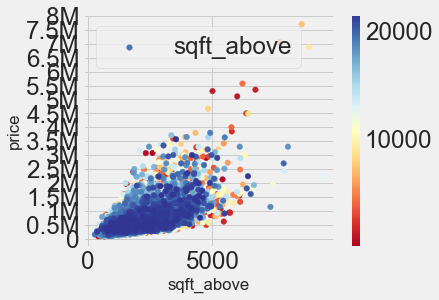

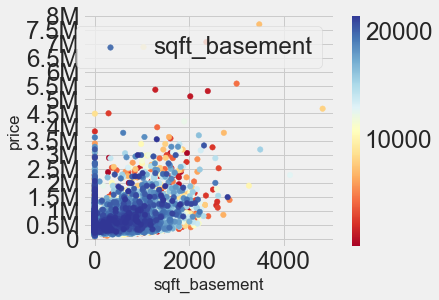

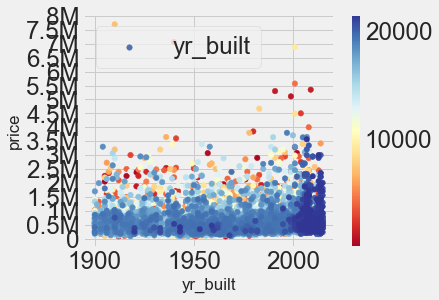

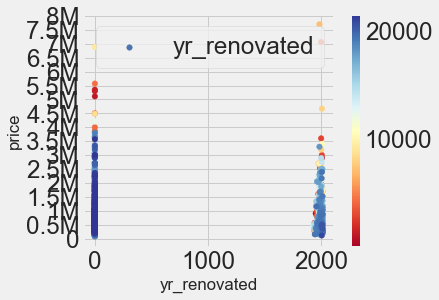

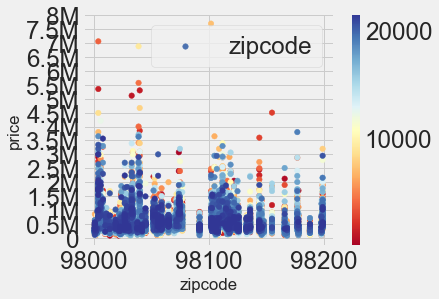

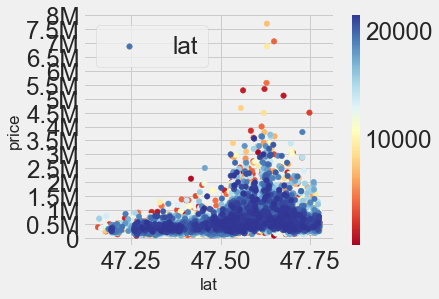

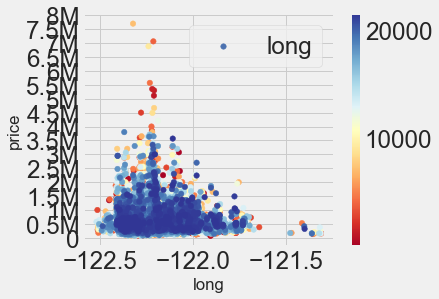

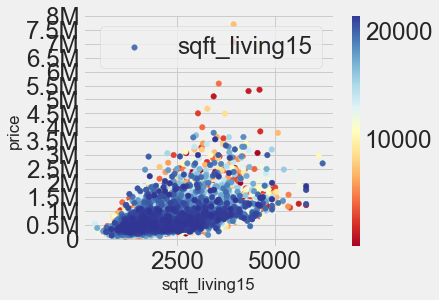

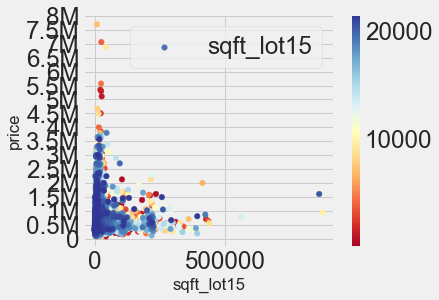

In [124]:

features = ['bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view','condition','grade','sqft_above','sqft_basement','yr_built','yr_renovated','zipcode','lat','long','sqft_living15','sqft_lot15']
feature_matrix = df[features]
#feature_matrix = preprocessing.scale(feature_matrix)
feature_matrix_unscaled = df[features]
lable_vector = df['price']
feature_matrix_unscaled.head()
style.use('fivethirtyeight')
cm = plt.cm.get_cmap('RdYlBu')
xy = range(1,21614)
z = xy
for feature in feature_matrix_unscaled:
    sc = plt.scatter(df[feature], df['price'], label = feature, c = z, marker = 'o', s = 30, cmap = cm)
    plt.colorbar(sc)
    plt.xlabel(''+feature)
    plt.ylabel('price')
    plt.yticks([0, 500000, 1000000, 1500000, 2000000, 2500000, 3000000, 3500000, 4000000, 4500000, 5000000, 5500000, 6000000, 6500000, 7000000, 7500000, 8000000],
            ['0', '0.5M', '1M', '1.5M', '2M', '2.5M', '3M',  '3.5M', '4M', '4.5M', '5M', '5.5M', '6M', '6.5M', '7M', '7.5M', '8M',])
    plt.legend()
    plt.show()

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\axisgrid.py:2065: UserWarning: The `size` parameter has been renamed to `height`; pleaes update your code.
  warnings.warn(msg, UserWarning)
C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


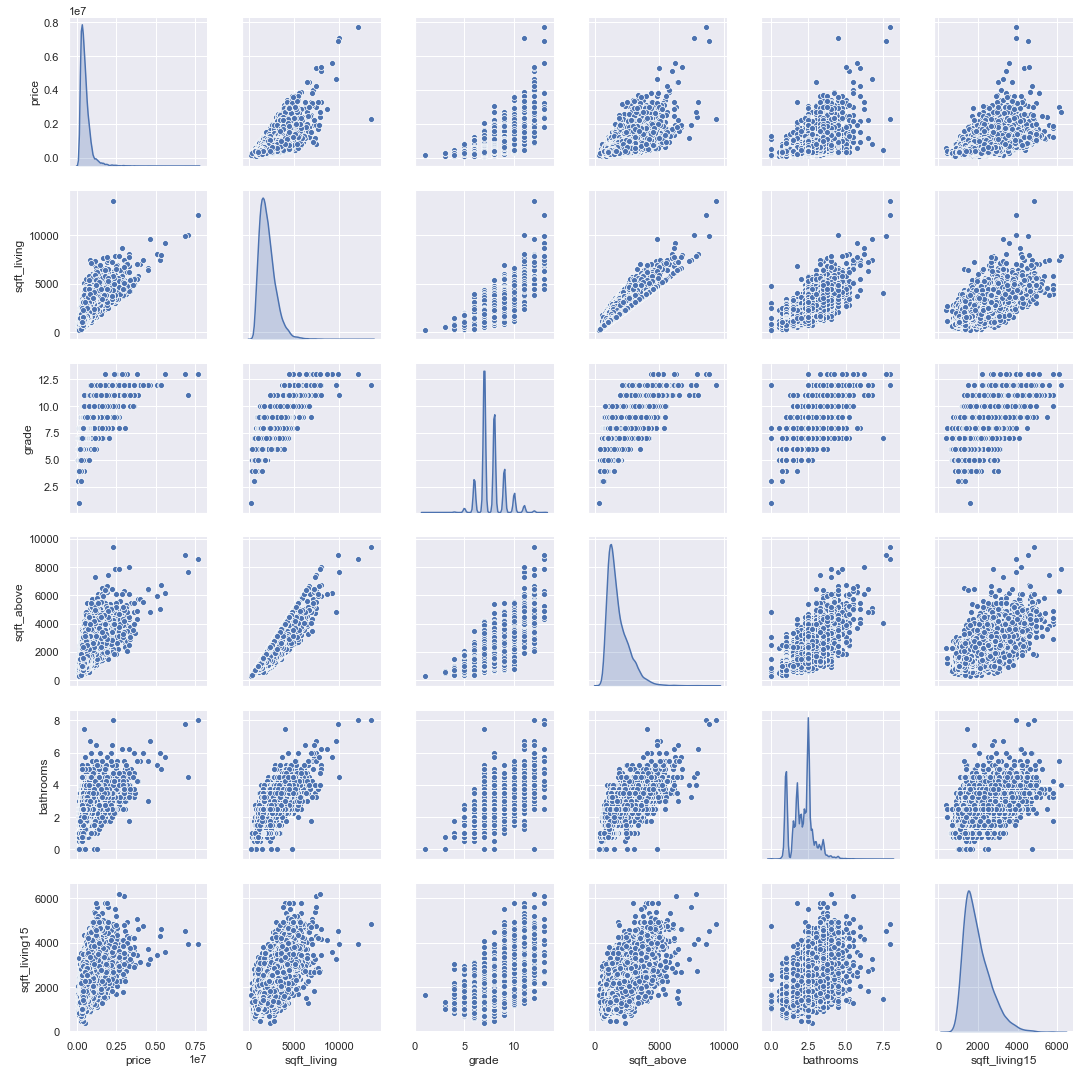

In [125]:
# Lets select the main variable (important features) and review the insigts by using pairplots 
sns.set()
cols = df[['price','sqft_living','grade','sqft_above','bathrooms','sqft_living15']]
sns.pairplot(cols, size = 2.5,diag_kind='kde')


# Linear regression

In [126]:
my_linear = LinearRegression()

In [127]:
my_linear.fit(feature_matrix, lable_vector)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [128]:

# printing Theta0 using attribute "intercept_":
print(my_linear.intercept_)

# printing [Theta1, Theta2, Theta3] using attribute "coef_":
print(my_linear.coef_)
coef_list = my_linear.coef_
# coef_list.sort()
print(coef_list)

6690324.603094982
[-3.57665414e+04  4.11442785e+04  1.10442865e+02  1.28597869e-01
  6.68955012e+03  5.82960458e+05  5.28709424e+04  2.63856491e+04
  9.58904452e+04  7.07852243e+01  3.96576400e+01 -2.62022321e+03
  1.98125837e+01 -5.82419866e+02  6.02748226e+05 -2.14729828e+05
  2.16814005e+01 -3.82641850e-01]
[-3.57665414e+04  4.11442785e+04  1.10442865e+02  1.28597869e-01
  6.68955012e+03  5.82960458e+05  5.28709424e+04  2.63856491e+04
  9.58904452e+04  7.07852243e+01  3.96576400e+01 -2.62022321e+03
  1.98125837e+01 -5.82419866e+02  6.02748226e+05 -2.14729828e+05
  2.16814005e+01 -3.82641850e-01]


# Sorting features based on co-efficient values from linear regression.

In [129]:
feature_dict = dict(zip(features, coef_list))
#print(feature_dict)
import operator
sorted_d = sorted(feature_dict.items(), key=operator.itemgetter(1),reverse=True)
print('Dictionary in descending order by value : ',sorted_d)

Dictionary in descending order by value :  [('lat', 602748.2264485789), ('waterfront', 582960.4584234204), ('grade', 95890.44515147552), ('view', 52870.94238431692), ('bathrooms', 41144.27853247383), ('condition', 26385.64913860337), ('floors', 6689.550115101832), ('sqft_living', 110.4428645998978), ('sqft_above', 70.78522433594844), ('sqft_basement', 39.65763997045087), ('sqft_living15', 21.68140046128974), ('yr_renovated', 19.812583709316357), ('sqft_lot', 0.12859786912304116), ('sqft_lot15', -0.38264184953732183), ('zipcode', -582.4198656402439), ('yr_built', -2620.2232112952465), ('bedrooms', -35766.54144373286), ('long', -214729.82825330136)]


# Checking best features vs price using pairplot

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\axisgrid.py:2065: UserWarning: The `size` parameter has been renamed to `height`; pleaes update your code.
  warnings.warn(msg, UserWarning)
C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


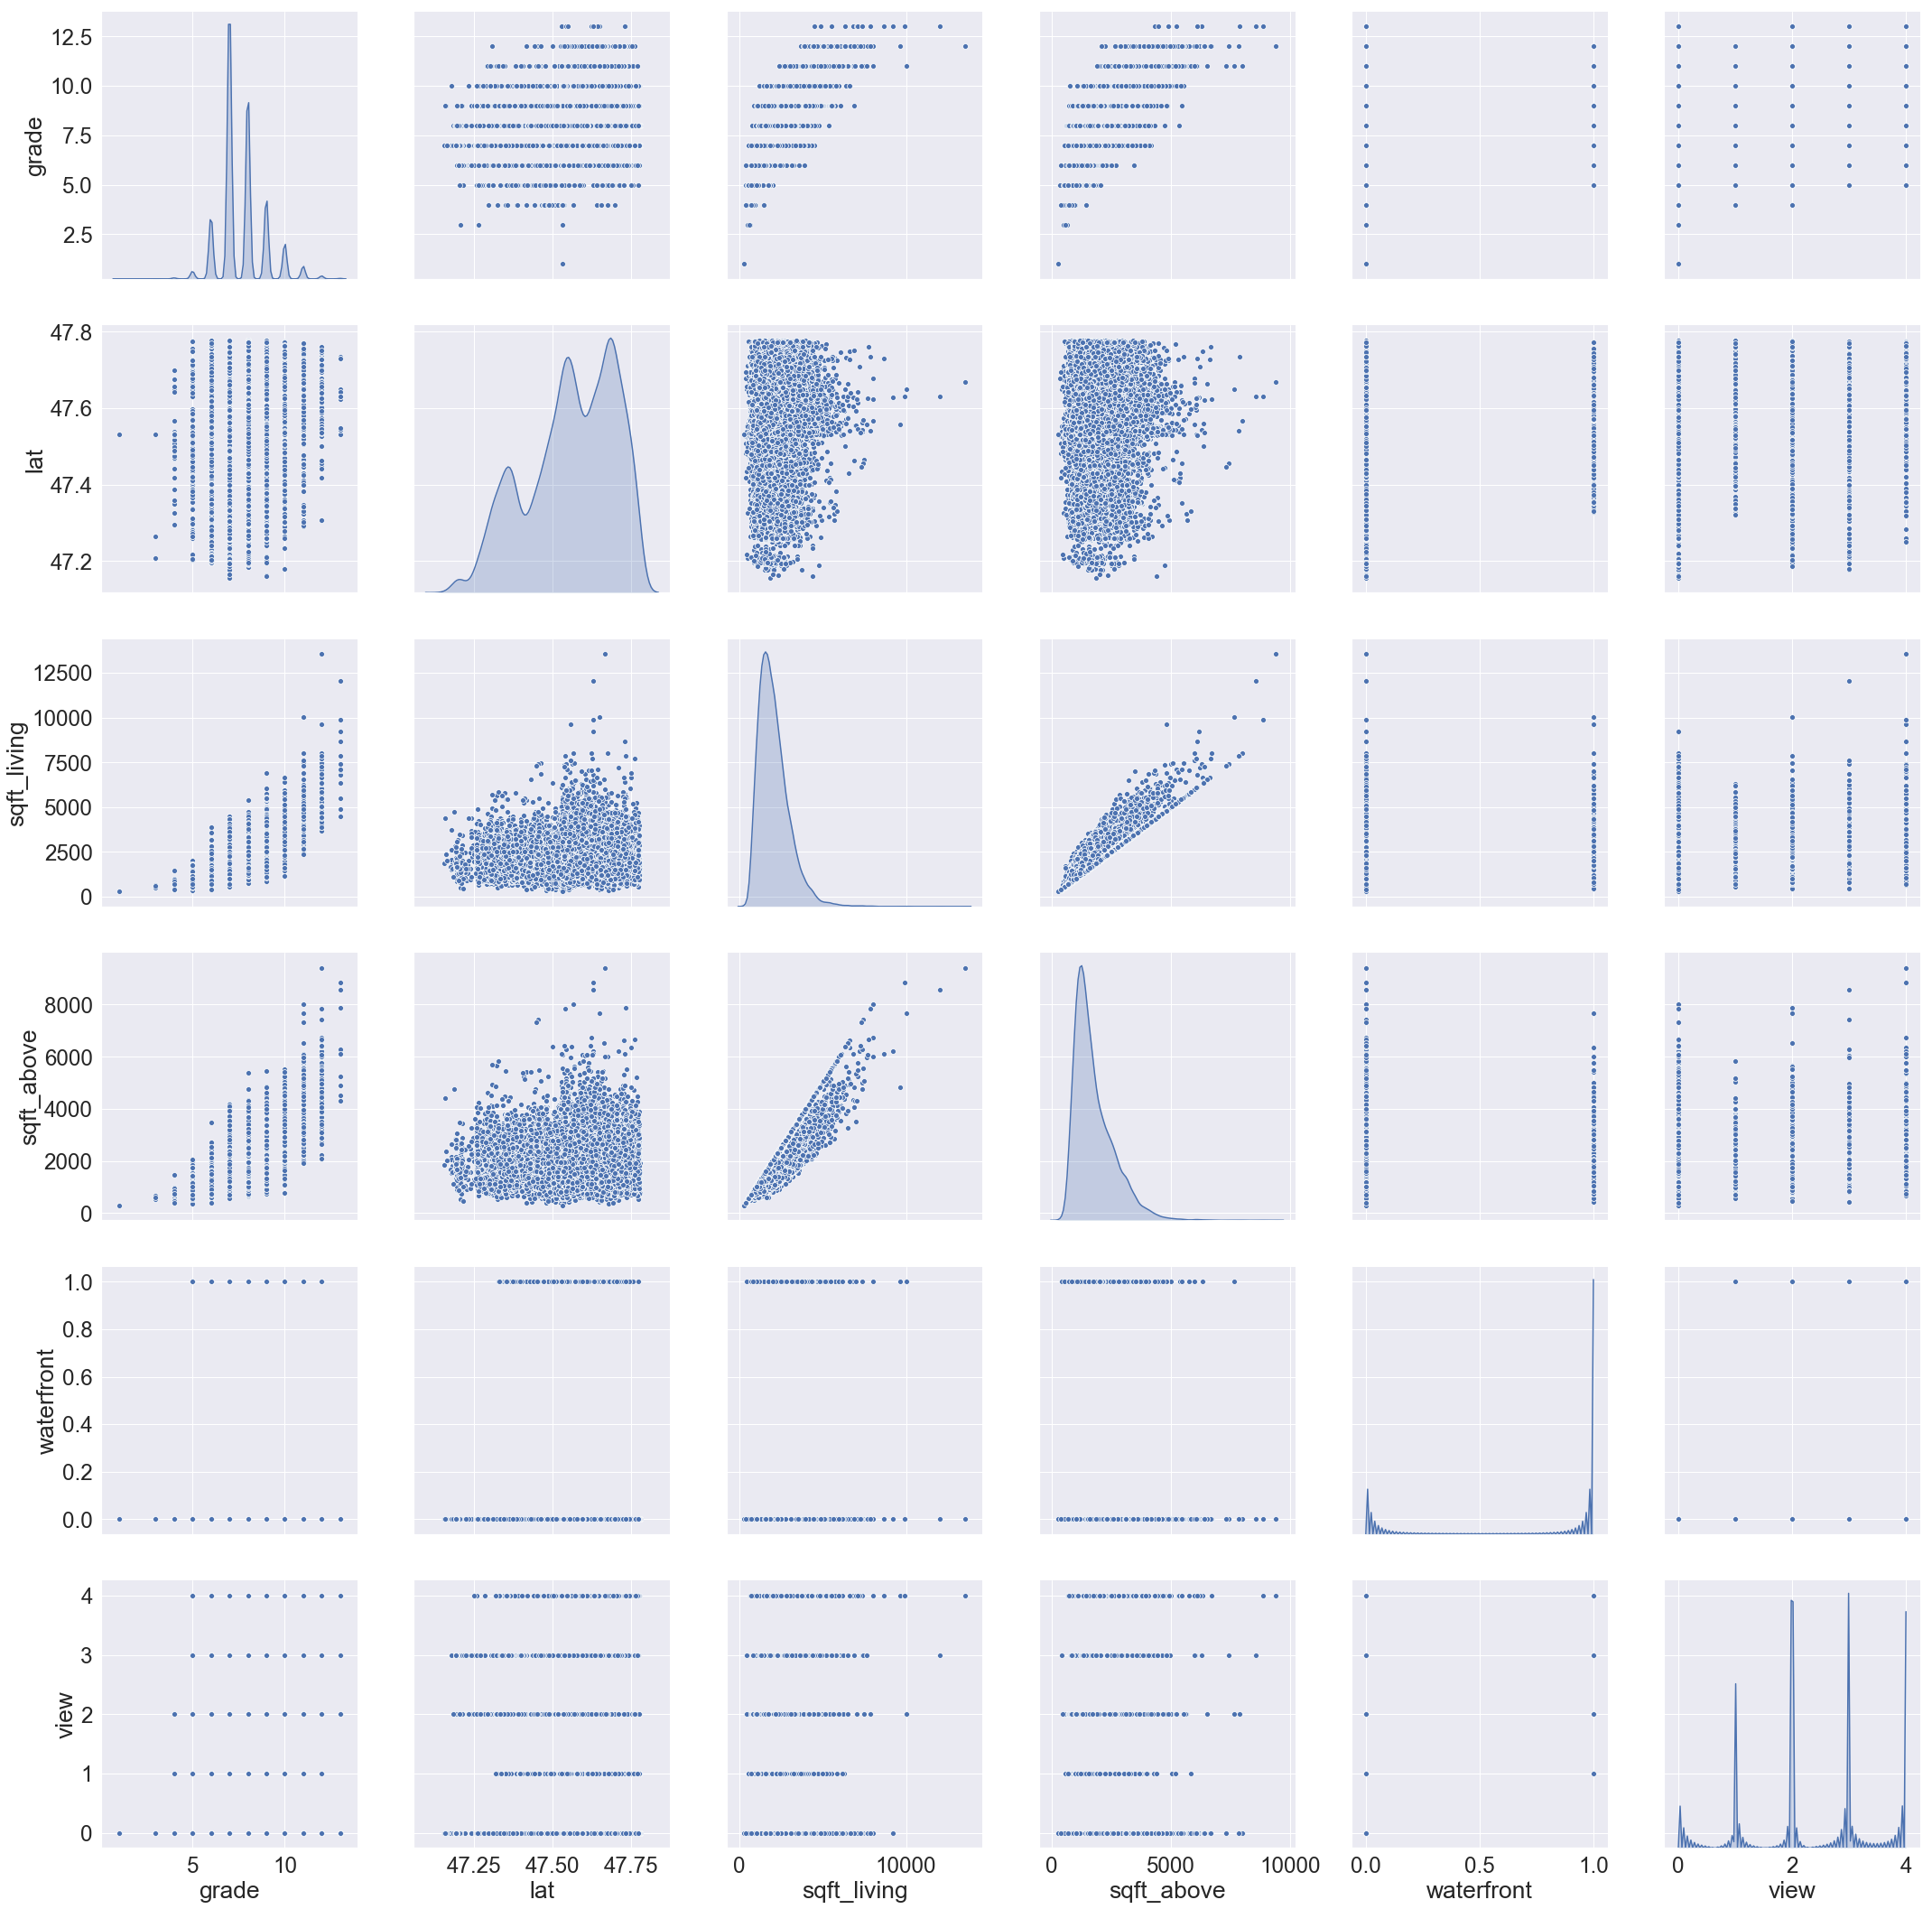

In [130]:
## Pairplot
##Scatterplot
sorted_features = ['grade','lat','sqft_living','sqft_above','waterfront','view']
sns.set(font_scale=2.2)
g = sns.pairplot(df[sorted_features] ,size=5,diag_kind='kde')
plt.show()


In [131]:

#sorting best features based on co-efficient values.
#sorted_features = ['sqft_living','sqft_basement','sqft_above','sqft_lot','yr_built','bedrooms']
#sorted_features = ['lat','waterfront','grade','view','bathrooms','condition'] # all features without scale
sorted_features = ['grade','lat','sqft_living','sqft_above','waterfront','view']
best_feature_matrix = df[sorted_features]
#scaling deature
#best_feature_matrix = preprocessing.scale(best_feature_matrix)

X_train, X_test, y_train, y_test = train_test_split(best_feature_matrix, lable_vector, test_size=0.3, random_state=3)
my_linear.fit(X_train, y_train)
y_predict_ln = my_linear.predict(X_test)
print(y_predict_ln)

[ 603611.88117212 1101117.79721396  833606.46564282 ...  205362.38746908
  364435.62431646  356653.08720752]


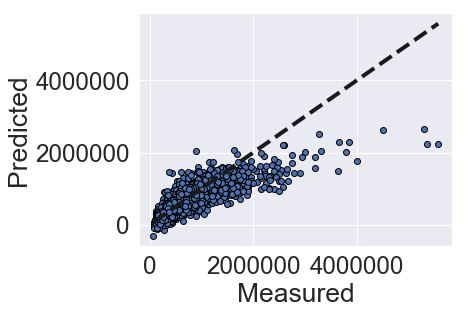

In [132]:
y_predict_ln = my_linear.predict(X_test)
fig, ax = plt.subplots()
ax.scatter(y_test, y_predict_ln, edgecolors=(0, 0, 0))
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_xlabel('Measured')
ax.set_ylabel('Predicted')
plt.show()

In [133]:
error = mean_squared_error(y_test, y_predict_ln)
root_mean_square_error = np.sqrt(error)
print("RMSE for liner regression>>>",root_mean_square_error)

RMSE for liner regression>>> 213098.2225629484


# KNN

In [134]:
k = 25
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)
y_predict_knn = knn.predict(X_test)
score_knn = accuracy_score(y_test, y_predict_knn)
print("KNN accuracy>>>>",score_knn)

KNN accuracy>>>> 0.005243676742751388


# Decision tree

In [135]:
my_decisiontree = DecisionTreeClassifier()
my_decisiontree.fit(X_train, y_train)
y_predict_dt = my_decisiontree.predict(X_test)
score_dt= accuracy_score(y_test, y_predict_dt)
print("Decision tree accuracy>>>>",score_dt)

Decision tree accuracy>>>> 0.008173966687230106


# Cross validation

In [136]:
kc_linear_reg = LinearRegression()
new_feature_marrix = preprocessing.scale(feature_matrix)
kc_mse = cross_val_score(kc_linear_reg,new_feature_marrix,lable_vector, cv=10, scoring='neg_mean_squared_error')


house_mse_positive = -kc_mse

house_rmse = np.sqrt(house_mse_positive)

print("RMSE for cross validation>>>",house_rmse.mean())

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:2: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by the scale function.
  


RMSE for cross validation>>> 201963.84367354706


# Random forest

In [137]:
my_RandomForest = RandomForestClassifier(n_estimators = 10, bootstrap = True, random_state=2)
my_RandomForest.fit(X_train,y_train) #train random forest classifier using training data
y_predict_rf=my_RandomForest.predict(X_test) #predict using testing data
score_rf=accuracy_score(y_test, y_predict_rf) #accuracy based on predicted values and original values
print("Accuracy for Random Forest>>>>> ",score_rf)

Accuracy for Random Forest>>>>>  0.010333127698951264


# PCA

In [138]:
n=6
my_pca = PCA(n_components=n)
feature_matrix_scaled = preprocessing.scale(feature_matrix)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(feature_matrix_scaled, lable_vector, test_size=0.3, random_state=3)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:3: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by the scale function.
  This is separate from the ipykernel package so we can avoid doing imports until


In [139]:
X_Train_new = my_pca.fit_transform(X_train_pca)
X_Test_new = my_pca.transform(X_test_pca)
print(X_Test_new.shape)
my_linear = LinearRegression()

(6484, 6)


In [140]:
my_linear.fit(X_Train_new, y_train_pca)
y_predict_ln = my_linear.predict(X_Test_new)#score_lr = accuracy_score(y_test, y_predict_ln)
error = mean_squared_error(y_test_pca, y_predict_ln) 
root_mean_square_error = np.sqrt(error) 
print("RMSE for PCA>>>>>>>",root_mean_square_error)

RMSE for PCA>>>>>>> 230708.65898577633


# Coefficient of determination

In [142]:
df['year_sell'] = [int(i[:4]) for i in df.date]

df.year_sell.value_counts().sort_index()


#test=kc_df[kc_df.year_sell==2015].reset_index(drop=True )
train=df[df.year_sell==2014].reset_index(drop=True )
x=train[df.columns.drop(['price','id','date'])]
y=train['price']
col=df.columns.drop(['price','id','date'])
clf = LinearRegression()
clf.fit(x,y)
score_dt = clf.score(x,y)
print("Determination>>>>>>",score_dt)

Determination>>>>>> 0.7072063380899662


# Adding features by taking square of each feature.

In [143]:
df_kc_square = pd.DataFrame()
for feature in features:
    df_kc_square[feature + '_square'] = df[feature]*df[feature]
print(df_kc_square.shape)

(21613, 18)


In [144]:
square_df = pd.concat([feature_matrix_unscaled, df_kc_square], axis=1)
square_df.shape

(21613, 36)

In [145]:

#normalize data
scaled_square_df = preprocessing.scale(square_df)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:3: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by the scale function.
  This is separate from the ipykernel package so we can avoid doing imports until
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:176: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn("Numerical issues were encountered "


# PCA on squared data

In [146]:
n=7
my_pca = PCA(n_components=n)
X_train_square, X_test_square, y_train_square, y_test_square = train_test_split(scaled_square_df, lable_vector, test_size=0.3, random_state=3)

In [147]:

X_Train_new = my_pca.fit_transform(X_train_square)
X_Test_new = my_pca.transform(X_test_square)
my_linear_squared = LinearRegression()

In [148]:
my_linear_squared.fit(X_Train_new, y_train_square)
y_predict_sq = my_linear_squared.predict(X_Test_new)#score_lr = accuracy_score(y_test, y_predict_ln)
error = mean_squared_error(y_test_square, y_predict_sq) 
root_mean_square_error = np.sqrt(error) 
print("RMSE for squared PCA>>>>>>>",root_mean_square_error)

RMSE for squared PCA>>>>>>> 204103.27627473456


# Cross validation on squared data

In [149]:
kc_linear_reg_square = LinearRegression()
kc_mse = cross_val_score(kc_linear_reg,scaled_square_df,lable_vector, cv=10, scoring='neg_mean_squared_error')


house_mse_positive = -kc_mse

house_rmse = np.sqrt(house_mse_positive)

print("RMSE for squared cross validation>>>",house_rmse.mean())

RMSE for squared cross validation>>> 188694.12653724116


# Polynomial Regression

In [150]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)
#print(X_train_poly.shape)
poly_lin_reg = LinearRegression()
poly_lin_reg.fit(X_train_poly, y_train)
y_predict_poly = poly_lin_reg.predict(X_test_poly)
print(y_predict_poly)

[ 542076.40412807 1149611.19659805  813265.28510284 ...  285321.15148926
  288119.73895168  360418.16966248]


In [151]:
# error = mean_squared_error(y_predict_poly, y_test)
#print(error)
root_mean_square_error = np.sqrt(error)
print("RMSE for polynomial regression>>>>>>>>",root_mean_square_error)

RMSE for polynomial regression>>>>>>>> 204103.27627473456


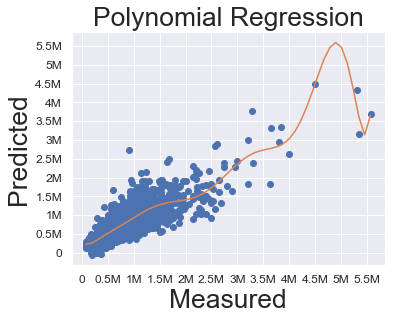

In [152]:
z = np.polyfit(y_test,y_predict_poly,10) 

p = np.poly1d(z)

plt.title ('Polynomial Regression')
plt.xlabel('Measured')
plt.ylabel('Predicted')
plt.yticks([0, 500000, 1000000, 1500000, 2000000, 2500000, 3000000, 3500000, 4000000, 4500000, 5000000, 5500000, 6000000, 6500000, 7000000, 7500000, 8000000],
            ['0', '0.5M', '1M', '1.5M', '2M', '2.5M', '3M',  '3.5M', '4M', '4.5M', '5M', '5.5M', '6M', '6.5M', '7M', '7.5M', '8M'], fontsize = 12)
plt.xticks([0, 500000, 1000000, 1500000, 2000000, 2500000, 3000000, 3500000, 4000000, 4500000, 5000000, 5500000, 6000000, 6500000, 7000000, 7500000, 8000000],
            ['0', '0.5M', '1M', '1.5M', '2M', '2.5M', '3M',  '3.5M', '4M', '4.5M', '5M', '5.5M', '6M', '6.5M', '7M', '7.5M', '8M'], fontsize = 12)
    

#plt.plot(y_test[:100], y_predict_poly[:100],'o-')
#plt.plot(y_test[:5], y_predict_poly[:5], '-')

datax_os = np.linspace(y_test.min(), y_test.max(), 50)
#plt.figure(figsize=(18,18))
plt.plot(y_test, y_predict_poly, 'o',datax_os, p(datax_os) ) # 'smoother' line

plt.show()


In [153]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_Train_new, y_train_square)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\ensemble\forest.py:246: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=None,
           max_features='auto', max_leaf_nodes=None,
           min_impurity_decrease=0.0, min_impurity_split=None,
           min_samples_leaf=1, min_samples_split=2,
           min_weight_fraction_leaf=0.0, n_estimators=10, n_jobs=None,
           oob_score=False, random_state=42, verbose=0, warm_start=False)

In [154]:
housing_predictions = forest_reg.predict(X_Train_new)
forest_mse = mean_squared_error( y_train_square, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

76163.08940396484

In [155]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())
forest_scores = cross_val_score(forest_reg,X_Train_new,y_train_square,
                             scoring="neg_mean_squared_error", cv=5)
tree_rmse_scores = np.sqrt(-forest_scores)
display_scores(tree_rmse_scores)

Scores: [184264.07482254 186379.99579445 186329.75695177 193758.84885436
 177711.04969069]
Mean: 185688.74522276185
Standard deviation: 5132.028989903451


In [156]:
from sklearn.model_selection import GridSearchCV

In [157]:
param_grid = [
    # try 12 (3×4) combinations of hyperparameters
    {'n_estimators': [3, 10, 30]},
    # then try 6 (2×3) combinations with bootstrap set as False
    {'bootstrap': [False], 'n_estimators': [3, 10]},
  ]

In [158]:
forest_reg = RandomForestRegressor(random_state=42)
# train across 5 folds, that's a total of (12+6)*5=90 rounds of training 
grid_search = GridSearchCV(forest_reg,param_grid, cv=5,
                           scoring='neg_mean_squared_error')
grid_search.fit(X_Train_new,y_train_square)

GridSearchCV(cv=5, error_score='raise-deprecating',
       estimator=RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=None,
           max_features='auto', max_leaf_nodes=None,
           min_impurity_decrease=0.0, min_impurity_split=None,
           min_samples_leaf=1, min_samples_split=2,
           min_weight_fraction_leaf=0.0, n_estimators='warn', n_jobs=None,
           oob_score=False, random_state=42, verbose=0, warm_start=False),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid=[{'n_estimators': [3, 10, 30]}, {'bootstrap': [False], 'n_estimators': [3, 10]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring='neg_mean_squared_error', verbose=0)

In [159]:
grid_search.best_params_
          
grid_search.best_estimator_
          
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

206423.56472950813 {'n_estimators': 3}
185760.17116088382 {'n_estimators': 10}
182701.64202139986 {'n_estimators': 30}
241216.79615492487 {'bootstrap': False, 'n_estimators': 3}
239979.48092154012 {'bootstrap': False, 'n_estimators': 10}


In [160]:
final_model = grid_search.best_estimator_ 

In [161]:
# Standardizing makes our data distributed normal and it is very usefull for a good prediction
final_predictions = final_model.predict(X_Test_new)

In [162]:
final_mse = mean_squared_error(y_test_square, final_predictions)
final_rmse = np.sqrt(final_mse)
          
final_rmse

173471.865131301

In [164]:
# RMSE for polynomial regression>>>>>>>> 204103.27627473456
# Accuracy results of KNN, Decision Tree Classifier also shared
# RMSE based on Gridsearch 182701.64202139986 {'n_estimators': 30}
# Cross Validation with Linear Regression.RMSE for squared cross validation>>> 188694.12653724116 
# Random Forest Regressor with Grid Search best estimator gives a result of 173471.865131301
# RandomForestRegressor has the least RMSE>>>>>76163.08940396484 (after PCA)

In [165]:
# Out of linear regression models go with CV and along-side Random Forest Regressor